# Scalability Report

Interactive view of the pairwise scalability benchmark. Reads the per-pair CSV written by `scripts/scalability_run.py` and renders distributional summaries, runtime-vs-model-size scatter, similarity-score distributions, and the slowest/fastest pairs.

This notebook is intended for reviewers who want to inspect the run beyond the headline numbers cited in the paper's maturity section.

**Per-pair pipeline.** Each row is one unordered pair (model_a, model_b) of BPMN files from `examples/company_models/`. The pipeline ran three stages, each timed independently. A **single set-similarity metric** is applied to both the structural and the behavioral dimension — the same contract enforced by the dashboard's single-method radio button. The CSV currently checked into the repo uses Dice; replace `--method` to regenerate with another choice.

- `t_semantic` — sentence-transformer name alignment (`normalize_atomic_names`, Alibaba-NLP/gte-large-en-v1.5, threshold 0.7).
- `t_structural` — set-based BPMN-element similarity (`calculate_bpmn_similarity`, method as configured).
- `t_behavioral` — Petri-net trace extraction on both sides (timeout 30 s per side, `max_loop_depth=2`) plus `calculate_trace_similarity` with the **same method** as the structural call.

`t_total` is the wall-clock for the whole pipeline on that pair, including everything outside the three stages (model lookup, CSV write).

## 1. Load the benchmark CSV

Default path is `results/scalability_run.csv`. To inspect a different run (e.g. a re-run with a different timeout), edit `CSV_PATH`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CSV_PATH = REPO_ROOT / 'results' / 'scalability_run.csv'

df = pd.read_csv(CSV_PATH)
print(f'CSV:    {CSV_PATH}')
print(f'rows:   {len(df)}')
print(f'columns: {list(df.columns)}')
df.head()

CSV:    /Users/I762870/dev/process-evaluation-framework/results/scalability_run.csv
rows:   11781
columns: ['pair_id', 'model_a', 'model_b', 'size_a', 'size_b', 't_semantic', 't_structural', 't_behavioral', 't_total', 'behavioral_timed_out_a', 'behavioral_timed_out_b', 'structural_overall', 'behavioral_score', 'error']


,pair_id,model_a,model_b,size_a,size_b,t_semantic,t_structural,t_behavioral,t_total,behavioral_timed_out_a,behavioral_timed_out_b,structural_overall,behavioral_score,error
0,0_1,model_1,model_2,4,16,0.764658,0.000188,0.004463,0.769311,False,False,0.075000,0.0,NaN
1,0_2,model_1,model_3,4,12,0.441162,0.000106,0.001849,0.443119,False,False,0.080000,0.0,NaN
2,0_3,model_1,model_4,4,13,0.270731,0.000108,0.010176,0.281017,False,False,0.067273,0.0,NaN
3,0_4,model_1,model_5,4,10,0.297468,0.000106,0.001285,0.298861,False,False,0.100000,0.0,NaN
4,0_5,model_1,model_6,4,11,0.281045,0.000112,0.005838,0.286997,False,False,0.062500,0.0,NaN


## 2. Run health

Counts of failed pairs and pairs that hit the Petri-net timeout on at least one side. Failed pairs (non-empty `error` column) are dropped from the numeric aggregation below; timeout pairs are kept (they did run, just with partial trace coverage).

In [2]:
errored = df[df['error'].notna() & (df['error'] != '')]
ok = df[~df.index.isin(errored.index)].copy()

# CSV stores booleans as the strings 'True' / 'False'. Coerce defensively.
def _as_bool(col):
    return col.astype(str).str.lower().map({'true': True, 'false': False}).fillna(False)

ok['behavioral_timed_out_a'] = _as_bool(ok['behavioral_timed_out_a'])
ok['behavioral_timed_out_b'] = _as_bool(ok['behavioral_timed_out_b'])
ok['behavioral_timed_out'] = ok['behavioral_timed_out_a'] | ok['behavioral_timed_out_b']

n_total = len(df)
n_err = len(errored)
n_ok = len(ok)
n_timeout = int(ok['behavioral_timed_out'].sum())

print(f'total pair rows:                 {n_total}')
print(f'  succeeded (no error):          {n_ok}')
print(f'  errored:                       {n_err}')
print(f'  with >=1 behavioral timeout:   {n_timeout}  ({100 * n_timeout / max(1, n_ok):.2f}% of OK pairs)')

if n_err:
    print('\nSample errors:')
    for _, row in errored.head(5).iterrows():
        print(f"  {row['pair_id']:>10}  {str(row['error'])[:200]}")

total pair rows:                 11781
  succeeded (no error):          11781
  errored:                       0
  with >=1 behavioral timeout:   6  (0.05% of OK pairs)


## 3. Corpus shape

Each model appears as either `model_a` or `model_b` in many pair rows; `size_a` / `size_b` record its flow-node count (activities + events + gateways). Reconstruct one row per distinct model to summarize the corpus.

distinct models:        154
flow-node count:        min=3, median=13, p95=37, max=52


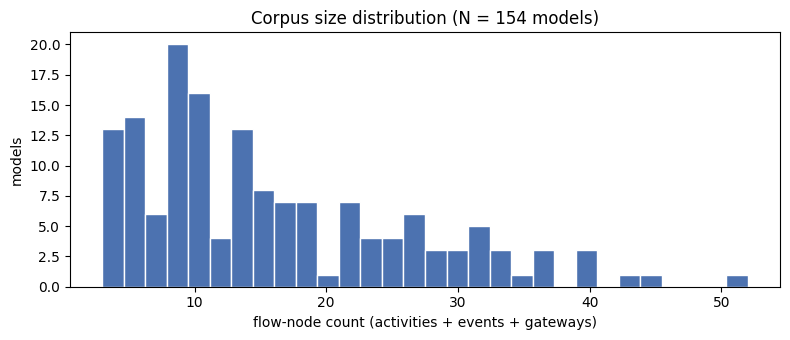

In [3]:
left = ok[['model_a', 'size_a']].rename(columns={'model_a': 'model', 'size_a': 'size'})
right = ok[['model_b', 'size_b']].rename(columns={'model_b': 'model', 'size_b': 'size'})
sizes = (
    pd.concat([left, right])
      .drop_duplicates(subset='model')
      .reset_index(drop=True)
      .sort_values('size')
)

print(f'distinct models:        {len(sizes)}')
print(f'flow-node count:        min={int(sizes["size"].min())}, '
      f'median={int(sizes["size"].median())}, '
      f'p95={int(sizes["size"].quantile(0.95))}, '
      f'max={int(sizes["size"].max())}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(sizes['size'], bins=30, color='#4c72b0', edgecolor='white')
ax.set_xlabel('flow-node count (activities + events + gateways)')
ax.set_ylabel('models')
ax.set_title(f'Corpus size distribution (N = {len(sizes)} models)')
plt.tight_layout(); plt.show()

## 4. Per-stage runtime distributions

Histograms of the per-pair wall-clock for each pipeline stage, plus `t_total`. **Log x-axis** because behavioral has a long tail spanning roughly six orders of magnitude (microseconds to tens of seconds), while structural is consistently in the microsecond range.

Below the histograms: a CDF showing the same distributions on shared axes, which is the cleaner way to compare them at a glance.

In [4]:
STAGES = [
    ('t_semantic',   'Semantic (normalize_atomic_names)',          '#dd8452'),
    ('t_structural', 'Structural (calculate_bpmn_similarity)',     '#55a868'),
    ('t_behavioral', 'Behavioral (extract_traces + trace metric)', '#c44e52'),
    ('t_total',      'Total pipeline',                             '#4c72b0'),
]

for col, _, _ in STAGES:
    ok[col] = pd.to_numeric(ok[col], errors='coerce')

stats_rows = []
for col, label, _ in STAGES:
    v = ok[col].dropna()
    stats_rows.append({
        'stage': label,
        'median': v.median(),
        'mean':   v.mean(),
        'p95':    v.quantile(0.95),
        'p99':    v.quantile(0.99),
        'max':    v.max(),
        'sum (s)': v.sum(),
    })
stats_df = pd.DataFrame(stats_rows)
# Print in seconds with sensible precision.
with pd.option_context('display.float_format', '{:.6f}'.format):
    print(stats_df.to_string(index=False))

                                     stage   median     mean      p95       p99       max     sum (s)
         Semantic (normalize_atomic_names) 0.018203 0.031869 0.094957  0.211472  1.259407  375.448350
    Structural (calculate_bpmn_similarity) 0.000139 0.000154 0.000296  0.000380  0.001032    1.815395
Behavioral (extract_traces + trace metric) 0.004842 0.564597 0.135506 23.519470 42.067239 6651.512204
                            Total pipeline 0.026087 0.596621 0.225163 23.581008 42.154203 7028.787597


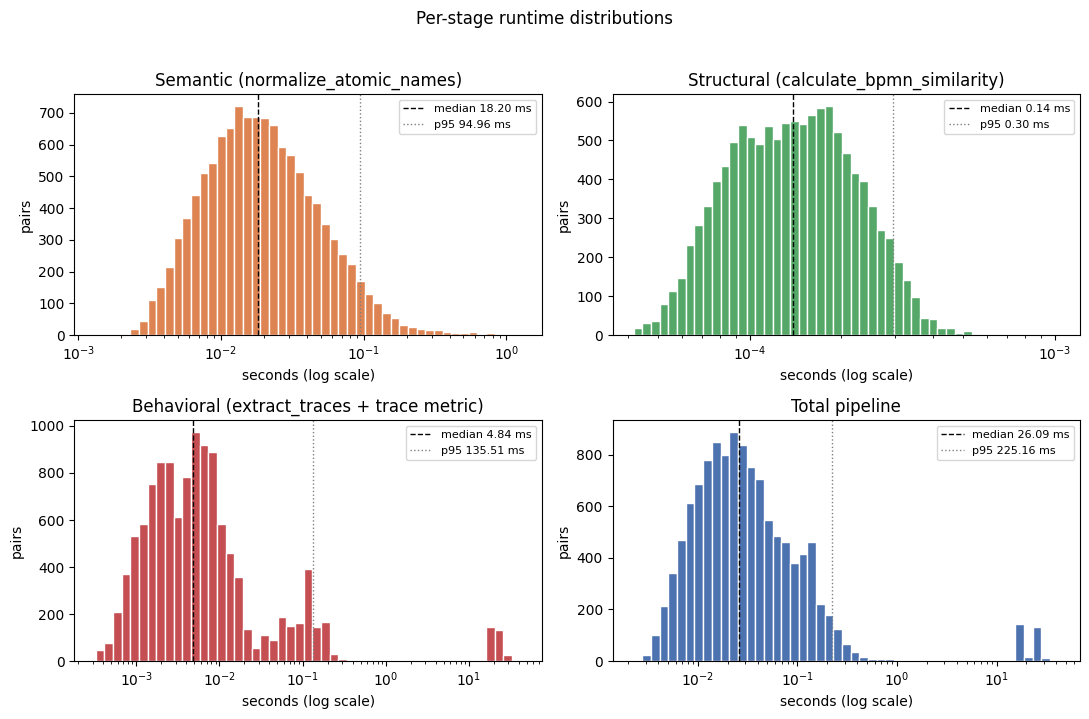

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for (col, label, color), ax in zip(STAGES, axes.flatten()):
    v = ok[col].dropna()
    v = v[v > 0]  # log scale needs positives
    ax.hist(v, bins=np.logspace(np.log10(v.min()), np.log10(v.max()), 50),
            color=color, edgecolor='white')
    ax.set_xscale('log')
    ax.set_xlabel('seconds (log scale)')
    ax.set_ylabel('pairs')
    ax.set_title(label)
    med = v.median(); p95 = v.quantile(0.95)
    ax.axvline(med, color='black', linestyle='--', linewidth=1, label=f'median {med*1000:.2f} ms')
    ax.axvline(p95, color='gray',  linestyle=':',  linewidth=1, label=f'p95 {p95*1000:.2f} ms')
    ax.legend(fontsize=8)
fig.suptitle('Per-stage runtime distributions', y=1.02)
plt.tight_layout(); plt.show()

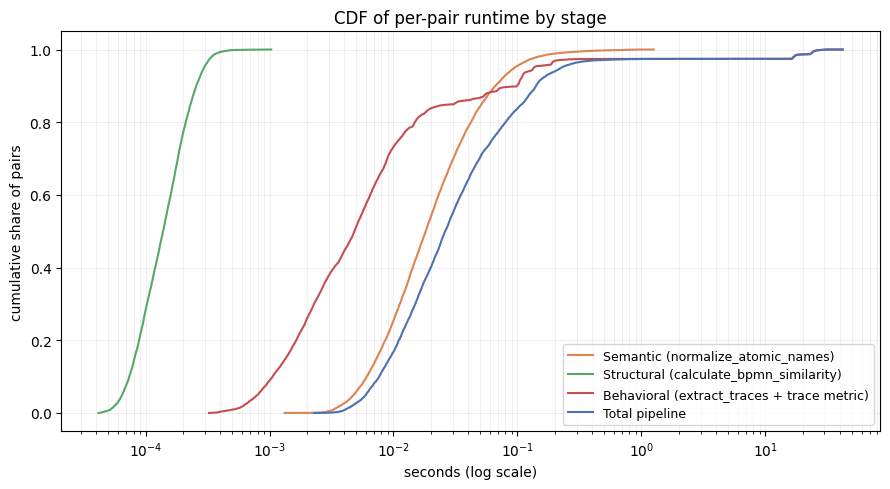

In [6]:
# CDF view on shared axes — clearest single comparison.
fig, ax = plt.subplots(figsize=(9, 5))
for col, label, color in STAGES:
    v = ok[col].dropna()
    v = np.sort(v[v > 0].values)
    if len(v) == 0:
        continue
    y = np.arange(1, len(v) + 1) / len(v)
    ax.plot(v, y, color=color, label=label, linewidth=1.5)
ax.set_xscale('log')
ax.set_xlabel('seconds (log scale)')
ax.set_ylabel('cumulative share of pairs')
ax.set_title('CDF of per-pair runtime by stage')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout(); plt.show()

**How to read this.** Where the curve sits to the left, the stage is fast; where it climbs steeply through a narrow range, the stage is tightly bounded. The structural curve is essentially a vertical line near 100 µs (set operations on small element lists). Semantic is a narrow band around 10–100 ms (sentence-transformer encoding, mostly amortized via cache). Behavioral has the longest tail by far — most pairs finish quickly, but a small fraction reach into the seconds range. This is the heavy tail that drives most of the total wall-clock.

## 5. Runtime vs. model size

For each pair, plot the behavioral runtime against the **larger** of the two models (the limiting side, since `extract_traces` is called on each side independently). If the heavy tail is predictable from size, it shows up as a clean upward sweep at the right edge of the plot.

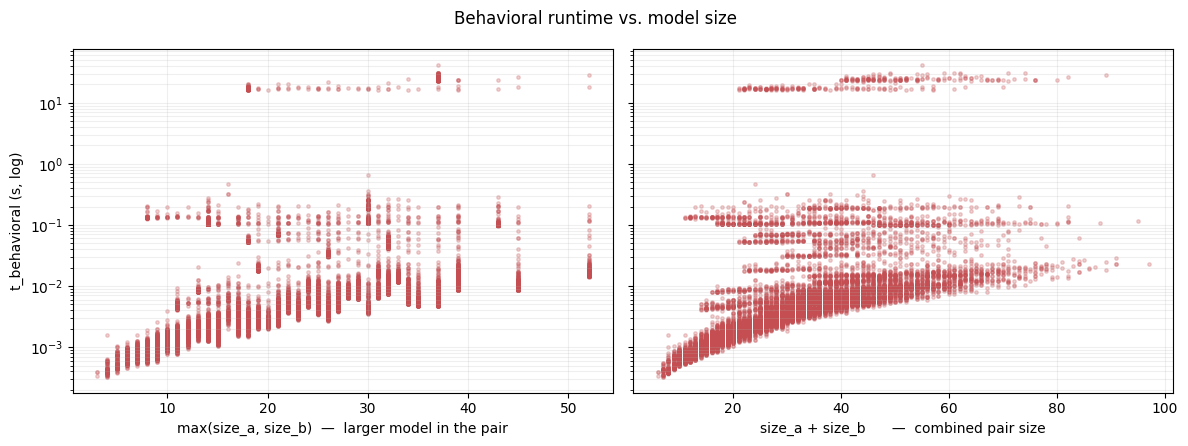

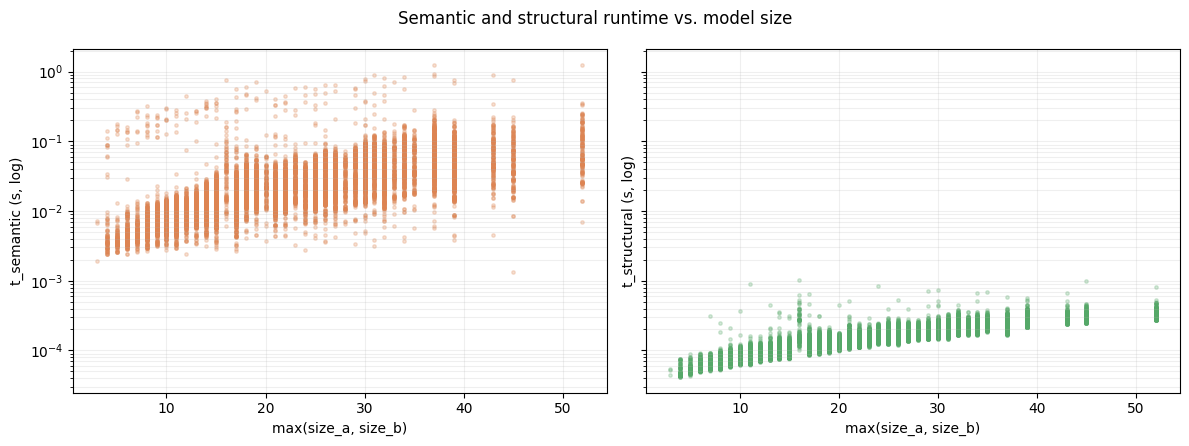

In [7]:
ok['size_max'] = ok[['size_a', 'size_b']].max(axis=1)
ok['size_sum'] = ok['size_a'] + ok['size_b']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, x_col, x_label in (
    (axes[0], 'size_max', 'max(size_a, size_b)  —  larger model in the pair'),
    (axes[1], 'size_sum', 'size_a + size_b      —  combined pair size'),
):
    ax.scatter(ok[x_col], ok['t_behavioral'], s=6, alpha=0.25, color='#c44e52')
    ax.set_yscale('log')
    ax.set_xlabel(x_label)
    ax.grid(True, which='both', alpha=0.2)
axes[0].set_ylabel('t_behavioral (s, log)')
fig.suptitle('Behavioral runtime vs. model size')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].scatter(ok['size_max'], ok['t_semantic'], s=6, alpha=0.25, color='#dd8452')
axes[0].set_yscale('log'); axes[0].set_xlabel('max(size_a, size_b)'); axes[0].set_ylabel('t_semantic (s, log)')
axes[1].scatter(ok['size_max'], ok['t_structural'], s=6, alpha=0.25, color='#55a868')
axes[1].set_yscale('log'); axes[1].set_xlabel('max(size_a, size_b)'); axes[1].set_ylabel('t_structural (s, log)')
for ax in axes:
    ax.grid(True, which='both', alpha=0.2)
fig.suptitle('Semantic and structural runtime vs. model size')
plt.tight_layout(); plt.show()

**How to read this.** Behavioral runtime scales roughly with the larger model's size, with substantial spread at each size — two models of the same node count can differ wildly because branching factor (number of gateways and message flows) drives the Petri-net state space, not raw node count. Semantic and structural are essentially flat in size: encoding cost is per-name (and cached), and set operations are bounded by the same node counts.

## 6. Similarity-score distributions

Distributions of the two reported scores across the 11k+ pairs. Useful for confirming the corpus has genuine variation (i.e. it is not all near-zero or all near-one) and to set expectations for reviewers about what scores look like on real enterprise BPMN models.

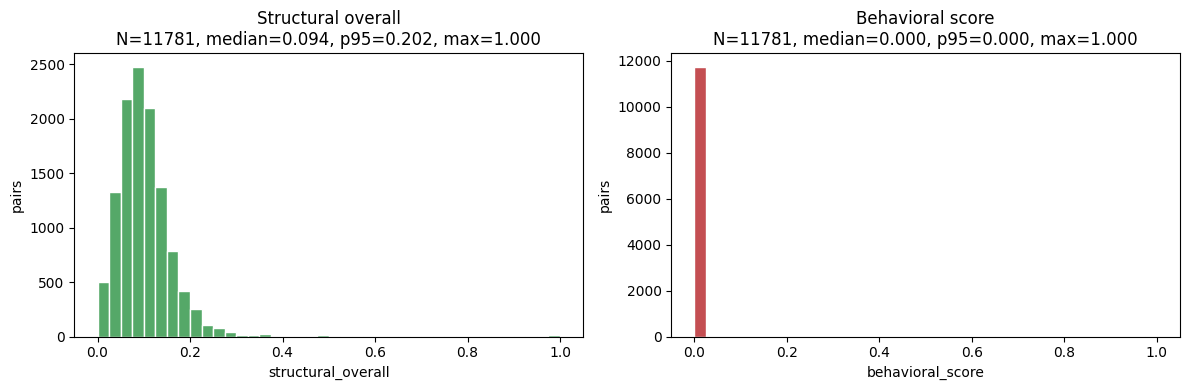

Score summary:
  structural_overall: median=0.094, mean=0.104, #zeros=55 (0.5%), #ones=16
  behavioral_score: median=0.000, mean=0.002, #zeros=11747 (99.7%), #ones=20


In [8]:
ok['structural_overall'] = pd.to_numeric(ok['structural_overall'], errors='coerce')
ok['behavioral_score'] = pd.to_numeric(ok['behavioral_score'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color, title in (
    (axes[0], 'structural_overall', '#55a868', 'Structural overall'),
    (axes[1], 'behavioral_score',   '#c44e52', 'Behavioral score'),
):
    v = ok[col].dropna()
    ax.hist(v, bins=40, color=color, edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('pairs')
    ax.set_title(f'{title}\nN={len(v)}, median={v.median():.3f}, '
                 f'p95={v.quantile(0.95):.3f}, max={v.max():.3f}')
plt.tight_layout(); plt.show()

print('Score summary:')
for col in ['structural_overall', 'behavioral_score']:
    v = ok[col].dropna()
    n_zero = int((v == 0).sum())
    n_one = int((v == 1).sum())
    print(f'  {col}: median={v.median():.3f}, mean={v.mean():.3f}, '
          f'#zeros={n_zero} ({100*n_zero/len(v):.1f}%), #ones={n_one}')

## 7. Top-N slowest and fastest pairs

Sortable tables of the most and least expensive pairs by `t_total`. The slowest pairs are the ones to investigate if the heavy tail looks suspicious. The fastest pairs are typically tiny-vs-tiny matchups that finish in well under a millisecond.

In [9]:
TOP_N = 20
show_cols = [
    'pair_id', 'model_a', 'model_b', 'size_a', 'size_b',
    't_semantic', 't_structural', 't_behavioral', 't_total',
    'behavioral_timed_out_a', 'behavioral_timed_out_b',
    'structural_overall', 'behavioral_score',
]

print(f'=== Top {TOP_N} slowest pairs ===')
slow = ok.nlargest(TOP_N, 't_total')[show_cols].copy()
with pd.option_context('display.max_colwidth', 40, 'display.width', 200, 'display.float_format', '{:.4f}'.format):
    print(slow.to_string(index=False))

=== Top 20 slowest pairs ===
pair_id   model_a   model_b  size_a  size_b  t_semantic  t_structural  t_behavioral  t_total  behavioral_timed_out_a  behavioral_timed_out_b  structural_overall  behavioral_score
 99_148 model_100 model_149      18      37      0.0867        0.0003       42.0672  42.1542                   False                   False              0.0654            0.0000
 17_148  model_18 model_149      37      37      0.1963        0.0003       30.5598  30.7565                   False                    True              0.2077            0.0000
 30_148  model_31 model_149      25      37      0.0929        0.0004       30.5352  30.6285                   False                    True              0.1326            0.0000
 19_148  model_20 model_149      22      37      0.0834        0.0003       30.4611  30.5448                   False                    True              0.1565            0.0000
 29_148  model_30 model_149      24      37      0.0737        0.0003       

In [10]:
print(f'=== Top {TOP_N} fastest pairs ===')
fast = ok.nsmallest(TOP_N, 't_total')[show_cols].copy()
with pd.option_context('display.max_colwidth', 40, 'display.width', 200, 'display.float_format', '{:.6f}'.format):
    print(fast.to_string(index=False))

=== Top 20 fastest pairs ===
pair_id  model_a   model_b  size_a  size_b  t_semantic  t_structural  t_behavioral  t_total  behavioral_timed_out_a  behavioral_timed_out_b  structural_overall  behavioral_score
  75_78 model_76  model_79       3       3    0.001906      0.000044      0.000334 0.002284                   False                   False            0.604167          0.000000
  75_77 model_76  model_78       3       4    0.002390      0.000045      0.000376 0.002811                   False                   False            0.362500          0.000000
   9_78 model_10  model_79       4       3    0.002423      0.000042      0.000347 0.002813                   False                   False            0.166071          0.000000
   9_75 model_10  model_76       4       3    0.002395      0.000042      0.000423 0.002861                   False                   False            0.232143          0.000000
  12_78 model_13  model_79       4       3    0.002430      0.000049      0.00039

## 8. Methodology footnote

The hardware / configuration line for the paper. Read off the running host, so it stays accurate if the benchmark is re-run on different hardware.

In [11]:
import platform, sys, subprocess

def _safe(cmd):
    try:
        return subprocess.check_output(cmd, stderr=subprocess.DEVNULL).decode().strip()
    except Exception:
        return None

cpu = _safe(['sysctl', '-n', 'machdep.cpu.brand_string']) or platform.processor() or 'unknown CPU'
ram_bytes = _safe(['sysctl', '-n', 'hw.memsize'])
ram = f'{int(ram_bytes) // (1024**3)} GB' if ram_bytes and ram_bytes.isdigit() else 'unknown RAM'

print('Hardware:')
print(f'  CPU:     {cpu}')
print(f'  RAM:     {ram}')
print(f'  OS:      {platform.platform()}')
print(f'  Python:  {sys.version.split()[0]}')
print()
print('Configuration (defaults — verify against the run that produced the CSV):')
print('  Petri-net timeout:        30.0 s per side')
print('  max_loop_depth:           2')
print('  Semantic threshold:       0.7')
print('  Sentence-transformer:     Alibaba-NLP/gte-large-en-v1.5')
print('  Set-similarity metric:    Dice')

Hardware:
  CPU:     Apple M2
  RAM:     24 GB
  OS:      macOS-26.5.1-arm64-arm-64bit
  Python:  3.11.0

Configuration (defaults — verify against the run that produced the CSV):
  Petri-net timeout:        30.0 s per side
  max_loop_depth:           2
  Semantic threshold:       0.7
  Sentence-transformer:     Alibaba-NLP/gte-large-en-v1.5
  Set-similarity metric:    Dice
